<a href="https://colab.research.google.com/github/RWANGOGA/Simulation-app/blob/madrine/anatomy_dataset_colab(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Anatomy textbooks to labelled dataset**Books live in Google Drive at `MyDrive/anatomy/` (the notebook also checks`MyDrive/anatomy/books/`). Run the cells in order.Everything is cached to Drive, so a cell you have already run is skipped onthe next runtime. Set `FORCE = True` in the setup cell to redo it anyway.

**1. Setup**

In [7]:
!pip install -q pymupdf pytesseract
!apt-get -qq install -y tesseract-ocr > /dev/null

import os, re, json, random, time, shutil, hashlib
from collections import Counter, defaultdict
import numpy as np, pandas as pd, matplotlib.pyplot as plt

try:
    import pymupdf as fitz
except ImportError:
    import fitz
import pytesseract
from PIL import Image
from sklearn.feature_extraction.text import TfidfVectorizer
from google.colab import drive

random.seed(42); np.random.seed(42)
drive.mount('/content/drive')

P = '/content/drive/MyDrive/anatomy'
RAW, DATA, EDA = f'{P}/raw', f'{P}/dataset', f'{P}/eda'
OCR = f'{P}/ocr_cache'
for d in (RAW, DATA, EDA, OCR):
    os.makedirs(d, exist_ok=True)

FORCE = False      # True = re-extract even if cached output exists
OCR_DPI = 200      # lower = faster, less accurate

# Books may sit in anatomy/ or anatomy/books/
found = []
for folder in (P, f'{P}/books'):
    if os.path.isdir(folder):
        for f in sorted(os.listdir(folder)):
            if f.lower().endswith(('.pdf', '.txt')):
                found.append(os.path.join(folder, f))

# Exclude 'ANATOMY_OF_THE_BODY.pdf' as requested by the user
found = [p for p in found if 'ANATOMY_OF_THE_BODY.pdf' not in p]

print(f'{len(found)} book(s):')
for p in found:
    print(f'  {os.path.basename(p):45s} '          f'{os.path.getsize(p)/1e6:6.1f} MB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
3 book(s):
  Anatomy-amp-Physiology-2e-1774993367.pdf       131.5 MB
  anatomy 2.pdf                                  101.6 MB
  anatomy3.pdf                                    34.6 MB


**2. Extract text**Checks each PDF for a text layer. If there is none the file is scannedimages, and the cell OCRs it instead, saving progress to Drive every 25pages so a disconnect does not cost you the work.OCR is slow — roughly 1 to 2 seconds per page, so a 1,400-page book takes30 to 50 minutes. For Gray's *Anatomy of the Human Body* there is a muchfaster route: download the plain-text version from`archive.org/details/anatomyofhumanbo1918gray` (left sidebar, "FULL TEXT"),drop the `.txt` into your `anatomy/` folder, and delete the scanned PDF.

In [11]:
def has_text_layer(doc, sample=25):
    idx = range(0, len(doc), max(1, len(doc)//sample))
    return sum(len(doc[i].get_text('text').strip()) for i in idx) > 500

def ocr_pdf(doc, name):
    # OCR page by page, checkpointing to Drive so a disconnect is recoverable
    ckpt = f'{OCR}/{name}.jsonl'
    done = {}
    if os.path.exists(ckpt) and not FORCE:
        for line in open(ckpt):
            d = json.loads(line)
            done[d['p']] = d['t']
        print(f'    resuming: {len(done)}/{len(doc)} pages already done')
    todo = [i for i in range(len(doc)) if i not in done]
    t0, n = time.time(), 0
    with open(ckpt, 'a') as fh:
        for i in todo:
            pix = doc[i].get_pixmap(dpi=OCR_DPI)
            img = Image.frombytes('RGB', (pix.width, pix.height), pix.samples)
            done[i] = pytesseract.image_to_string(img)
            fh.write(json.dumps({'p': i, 't': done[i]}) + '\n')
            n += 1
            if n % 25 == 0:
                fh.flush(); os.fsync(fh.fileno())
                rate = (time.time() - t0) / n
                left = (len(todo) - n) * rate / 60
                print(f'    page {i+1}/{len(doc)}  '\
                      f'{rate:.1f}s/page  ~{left:.0f} min left')
    return [done[i] for i in range(len(doc))]

def read_pages(path):
    name = os.path.splitext(os.path.basename(path))[0]
    if path.lower().endswith('.txt'):
        t = open(path, encoding='utf-8', errors='ignore').read()
        return [t[i:i+3000] for i in range(0, len(t), 3000)], False
    doc = fitz.open(path)
    if has_text_layer(doc):
        pages = [pg.get_text('text') for pg in doc]
        doc.close()
        return pages, False
    print('    no text layer -> OCR')
    pages = ocr_pdf(doc, name)
    doc.close()
    return pages, True

def strip_headers(pages):
    # Drop short lines appearing at the edge of more than 25% of pages
    edge = Counter()
    for p in pages:
        lines = [l.strip() for l in p.split('\n') if l.strip()]
        for l in lines[:2] + lines[-2:]:
            if len(l) < 90:
                edge[l] += 1
    cut = max(3, int(len(pages) * 0.25))
    boiler = {l for l, c in edge.items() if c >= cut}
    out = ['\n'.join(l for l in p.split('\n')\
                     if l.strip() not in boiler) for p in pages]
    return out, len(boiler)

def clean(t, ocred=False):
    t = re.sub(r'(\w)-\s*\n\s*(\w)', r'\1\2', t)
    t = re.sub(r'\n\s*\d{1,4}\s*\n', '\n', t)
    t = re.sub(r'(?m)^\s*(Figure|Fig\.|Table|Plate)\s*[\d.]+.*$', '', t)
    if ocred:
        # OCR noise: lines that are mostly non-letters are scan artefacts
        keep = []
        for l in t.split('\n'):
            letters = sum(c.isalpha() or c.isspace() for c in l)
            if not l.strip() or letters / max(1, len(l)) > 0.75:
                keep.append(l)
        t = '\n'.join(keep)
    t = re.sub(r'(?<![.\u200B?!:])\\n(?!\\n)', ' ', t)
    t = re.sub(r'\n{3,}', '\n\n', t)
    return re.sub(r'[ \t]{2,}', ' ', t).strip()

for path in found:
    name = os.path.splitext(os.path.basename(path))[0]
    out = f'{RAW}/{name}.txt'
    if os.path.exists(out) and not FORCE:
        n = len(open(out).read().split())
        print(f'{name}: cached ({n:,} words) - skipping')
        continue
    print(f'{name}:')
    pages, ocred = read_pages(path)
    pages, nb = strip_headers(pages)
    text = clean('\n\n'.join(pages), ocred)
    open(out, 'w').write(text)
    print(f'    {len(pages)} pages, {nb} boilerplate lines cut, '\
          f'{len(text.split()):,} words\n')

print('--- SAMPLE. READ THIS BEFORE CONTINUING ---')
for f in sorted(os.listdir(RAW)):
    print(f'\n### {f}\n{open(f"{RAW}/{f}").read(600)}')


Anatomy-amp-Physiology-2e-1774993367:
    1879 pages, 0 boilerplate lines cut, 630,861 words

anatomy 2:
    193 pages, 0 boilerplate lines cut, 68,123 words

anatomy3:
    495 pages, 0 boilerplate lines cut, 259,654 words

--- SAMPLE. READ THIS BEFORE CONTINUING ---

### Anatomy-amp-Physiology-2e-1774993367.txt
Anatomy & Physiology 2e 

ANATOMY & PHYSIOLOGY 2E 
LINDSAY M. BIGA; STACI BRONSON; SIERRA DAWSON; AMY HARWELL; ROBIN HOPKINS; JOEL KAUFMANN; MIKE LEMASTER; PHILIP MATERN; KATIE MORRISON-GRAHAM; KRISTEN OJA; DEVON QUICK; JON RUNYEON; AND OPENSTAX 
Oregon State University 
Corvallis, OR 

Anatomy & Physiology 2e Copyright © 2025 by Lindsay M. Biga, Staci Bronson, Sierra Dawson, Amy Harwell, Robin Hopkins, Joel Kaufmann, Mike LeMaster, Philip Matern, Katie 
Morrison-Graham, Kristen Oja, Devon Quick, Jon Runyeon, and OpenStax is licensed under a Creative Commons Attribution-ShareAlike 4.0 Internat

### anatomy 2.txt
94 
, 
V 
C's 
* © 
+$$$$$$$$$$0$+$++ 
fff 
-++4$$+3dd0dPhi++ #4 


**3. Body-system lexicons**Labels come from these term lists. This is the cell worth your time — addterms from your textbooks' indexes. A class that comes out near zero belowhas a thin list, not a missing topic.

In [14]:
LEX = {'skeletal': '''bone bones osseous skeleton skeletal femur tibia fibula humerus  radius ulna clavicle scapula sternum rib ribs vertebra vertebrae vertebral  spine cranium skull mandible maxilla occipital parietal temporal sphenoid  ethmoid pelvis ilium ischium pubis sacrum coccyx patella carpal tarsal  metacarpal metatarsal phalanx phalanges periosteum osteocyte osteoblast  osteoclast ossification epiphysis diaphysis marrow cartilage joint joints  articulation ligament suture condyle trochanter tubercle foramen''','muscular': '''muscle muscles muscular myofibril sarcomere actin myosin tendon  aponeurosis deltoid biceps triceps pectoralis trapezius latissimus gluteus  sartorius gastrocnemius soleus quadriceps hamstring masseter rectus oblique  sternocleidomastoid contraction sarcolemma sarcoplasmic myocyte fascicle  flexor extensor abductor adductor striated''','nervous': '''nerve nerves neuron neurons neural brain cerebrum cerebellum  cortex cortical medulla pons midbrain thalamus hypothalamus hippocampus  amygdala spinal cord meninges dura arachnoid pia synapse synaptic axon  dendrite myelin glia astrocyte oligodendrocyte ganglion plexus reflex  neurotransmitter acetylcholine dopamine depolarization sympathetic  parasympathetic autonomic''','cardiovascular': '''heart cardiac myocardium endocardium pericardium atrium  atria ventricle ventricles valve mitral tricuspid aortic aorta artery  arteries arteriole capillary capillaries vein veins venule cava blood  plasma erythrocyte leukocyte platelet hemoglobin circulation systole  diastole coronary sinoatrial atrioventricular purkinje pulse hematocrit  coagulation''','respiratory': '''lung lungs pulmonary respiration respiratory breathing  trachea bronchus bronchi bronchiole alveolus alveoli alveolar pleura  pleural larynx pharynx epiglottis surfactant ventilation oxygen  inspiration expiration diaphragm intercostal spirometry hypoxia''','digestive': '''digestion digestive alimentary esophagus stomach gastric  intestine intestinal duodenum jejunum ileum colon cecum rectum anus liver  hepatic gallbladder bile pancreas pancreatic villi microvilli peristalsis  chyme amylase pepsin lipase absorption mucosa submucosa mesentery salivary  tongue teeth''','endocrine': '''endocrine hormone hormones gland pituitary hypophysis thyroid  parathyroid adrenal cortisol aldosterone insulin glucagon islet langerhans  pineal melatonin oxytocin vasopressin prolactin somatotropin thyroxine  calcitonin epinephrine norepinephrine secretion''','lymphatic_immune': '''lymph lymphatic lymphocyte spleen thymus tonsil immune  immunity antibody antigen immunoglobulin macrophage phagocyte inflammation  complement cytokine interferon histamine vaccination pathogen infection  lacteal edema''','urinary': '''kidney kidneys renal nephron glomerulus glomerular bowman tubule  collecting ureter bladder urethra urine urination micturition filtration  reabsorption creatinine urea juxtaglomerular renin erythropoietin papilla''','integumentary': '''skin epidermis dermis hypodermis keratin keratinocyte  melanin melanocyte follicle sebaceous sweat sudoriferous nail stratum  corneum basale granulosum spinosum collagen elastin subcutaneous  integument cutaneous''','reproductive': '''reproductive gonad testis testes ovary ovaries uterus  uterine fallopian oviduct vagina cervix penis scrotum prostate seminal  epididymis deferens spermatozoon sperm oocyte ovum ovulation menstrual  endometrium myometrium placenta gamete meiosis fertilization estrogen  progesterone testosterone'''}
LEX = {k: set(v.split()) for k, v in LEX.items()}
LABELS = sorted(LEX)
for k in LABELS:
    print(f'{k:20s} {len(LEX[k])} terms')

cardiovascular       39 terms
digestive            35 terms
endocrine            26 terms
integumentary        23 terms
lymphatic_immune     23 terms
muscular             35 terms
nervous              41 terms
reproductive         33 terms
respiratory          27 terms
skeletal             60 terms
urinary              23 terms


**4. Build the dataset**Splits books into passages, removes duplicates, labels them, writestrain/val/test.Deduplication matters here: your OpenStax file and any derived text sharesource material, so without it the same passage lands in train and test andevery model's accuracy is inflated. MinHash finds candidate pairs cheaplyand true Jaccard similarity confirms before anything is deleted.

In [21]:
MIN_W, MAX_W = 30, 300       # passage size in words
MIN_HITS, MIN_MARGIN = 3, 2  # label confidence thresholds
JACCARD = 0.80               # near-duplicate cutoff
rows = []
for f in sorted(os.listdir(RAW)):
    book = os.path.splitext(f)[0]
    n0 = len(rows)
    for i, para in enumerate(re.split(r'\n\s*\n', open(f'{RAW}/{f}').read())):
        w = para.split()
        if len(w) < MIN_W:
            continue
        for j in range(0, len(w), MAX_W):
            if len(w[j:j+MAX_W]) >= MIN_W:
                rows.append({'book': book, 'para_idx': i,
                             'text': ' '.join(w[j:j+MAX_W])})
    print(f'{book}: {len(rows)-n0:,} passages')

# deduplicate: MinHash + LSH banding, verified with true Jaccard
NP, BANDS = 64, 16
R, M = NP // BANDS, (1 << 32) - 1
PERMS = [(random.randrange(1, M), random.randrange(0, M)) for _ in range(NP)]

def shingle(t, k=5):
    w = re.sub(r'\W+', ' ', t.lower()).split()
    if len(w) < k:
        return {' '.join(w)} if w else set()
    return {' '.join(w[i:i+k]) for i in range(len(w)-k+1)}

def sig_of(sh):
    h = [int(hashlib.md5(s.encode()).hexdigest()[:8], 16) for s in sh]
    return tuple(min((a*x + b) & M for x in h) for a, b in PERMS)

seen, buckets, keep, keep_sh = set(), defaultdict(list), [], []
n_exact = n_near = 0
for r in rows:
    norm = re.sub(r'\W+', ' ', r['text'].lower()).strip()
    h = hashlib.md5(norm.encode()).hexdigest()
    if h in seen:
        n_exact += 1
        continue
    seen.add(h)
    sh = shingle(r['text'])
    sig = sig_of(sh)
    bands = [(b, sig[b*R:(b+1)*R]) for b in range(BANDS)]
    cand = set()
    for bd in bands:
        cand.update(buckets[bd])
    if any(len(sh & keep_sh[i]) / len(sh | keep_sh[i]) >= JACCARD
           for i in cand if sh | keep_sh[i]):
        n_near += 1
        continue
    for bd in bands:
        buckets[bd].append(len(keep))
    keep.append(r); keep_sh.append(sh)

print(f'\nremoved {n_exact:,} exact + {n_near:,} near-duplicates, '\
      f'kept {len(keep):,} of {len(rows):,}')
rows = keep

labelled, dropped = [], 0
for r in rows:
    toks = set(re.findall(r'[a-z]+', r['text'].lower()))
    sc = sorted(((len(toks & v), k) for k, v in LEX.items()), reverse=True)
    if sc[0][0] >= MIN_HITS and sc[0][0] - sc[1][0] >= MIN_MARGIN:
        r['label'], r['confidence'] = sc[0][1], sc[0][0]
        labelled.append(r)
    else:
        dropped += 1
print(f'labelled {len(labelled):,}, discarded {dropped:,} as ambiguous\n')

dist = Counter(r['label'] for r in labelled)
for k in LABELS:
    n = dist.get(k, 0)
    flag = '  <-- thin lexicon, add terms' if n < len(labelled)*0.01 else ''
    print(f'{k:20s} {n:6,}{flag}')

# split, grouped by paragraph so chunks never straddle train and test
groups = defaultdict(list)
for r in labelled:
    groups[(r['book'], r['para_idx'])].append(r)

by_lab = defaultdict(list)
for k, v in groups.items():
    by_lab[v[0]['label']].append(k)

tr, va, te = [], [], [] # Initialize tr, va, te as empty lists

for lab, keys in by_lab.items():
    random.shuffle(keys)
    a, b = int(.70*len(keys)), int(.85*len(keys))
    for k in keys[:a]:  tr += groups[k]
    for k in keys[a:b]: va += groups[k]
    for k in keys[b:]:  te += groups[k]

for s in (tr, va, te):
    random.shuffle(s)

cols = ['book', 'para_idx', 'label', 'confidence', 'text']
frames = {}
for name, s in [('train', tr), ('val', va), ('test', te), ('all', labelled)]:
    frames[name] = pd.DataFrame(s, columns=cols)
    frames[name].to_csv(f'{DATA}/{name}.csv', index=False)
    print(f'\n{name:5s} {len(s):6,}  -> {DATA}/{name}.csv', end='')

json.dump(LABELS, open(f'{DATA}/labels.json', 'w'), indent=2)

if min(len(tr), len(va), len(te)) == 0:
    print('\n\nWARNING: a split came out empty. Too little text survived')
    print('labelling. Widen the lexicon or lower MIN_HITS, then re-run.')

lk = len(set(frames['train']['text']) & set(frames['test']['text']))
print(f'\n\nLEAKAGE CHECK: {lk} passages in both train and test')
print('Clean.' if lk == 0 else 'NOT CLEAN - do not train until this is 0.')

Anatomy-amp-Physiology-2e-1774993367: 2,939 passages
anatomy 2: 265 passages
anatomy3: 1,076 passages

removed 15 exact + 63 near-duplicates, kept 4,202 of 4,280
labelled 2,369, discarded 1,833 as ambiguous

cardiovascular          399
digestive               194
endocrine               160
integumentary            89
lymphatic_immune        113
muscular                108
nervous                 399
reproductive            173
respiratory             116
skeletal                522
urinary                  96

train  1,657  -> /content/drive/MyDrive/anatomy/dataset/train.csv
val      352  -> /content/drive/MyDrive/anatomy/dataset/val.csv
test     360  -> /content/drive/MyDrive/anatomy/dataset/test.csv
all    2,369  -> /content/drive/MyDrive/anatomy/dataset/all.csv

LEAKAGE CHECK: 0 passages in both train and test
Clean.


**5. EDA and label validation**Read the 50 sample passages at the bottom and count how many labels arecorrect. That fraction is your label accuracy and it caps what any model canreach. Report it in your methods — a weakly supervised dataset with ameasured label accuracy is defensible, one without is not.

Passages   : 2,369
Books      : 3   Classes: 11
Total words: 567,262
Per passage: mean 239, median 300, p95 300
Vocabulary : 17,065 word types
Imbalance  : 5.9x
  -> use macro-F1 as headline metric and class weights
Truncated  : 0.0% exceed ~512 tokens

label
skeletal            522
nervous             399
cardiovascular      399
digestive           194
reproductive        173
endocrine           160
respiratory         116
lymphatic_immune    113
muscular            108
urinary              96
integumentary        89


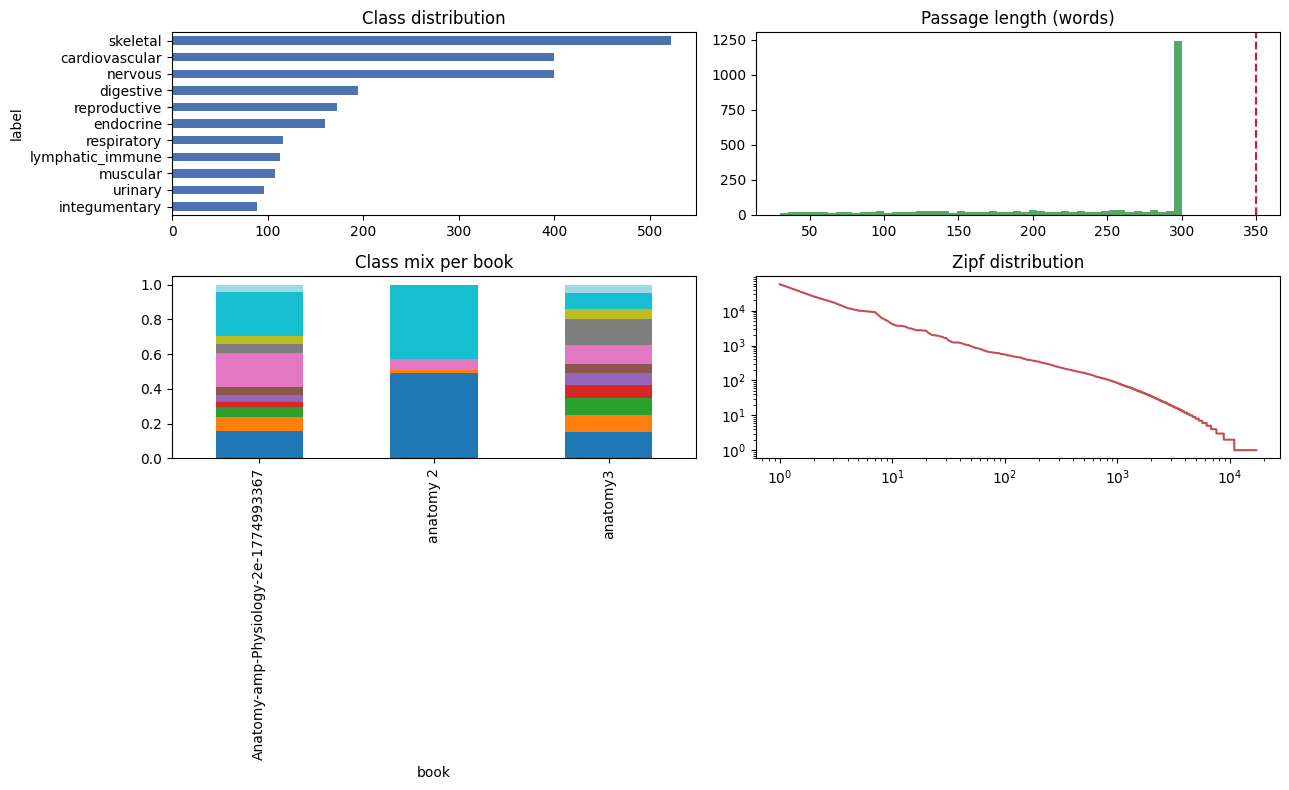


Top terms per class [n from lexicon]:
  skeletal           [8/10]  bone, bones, joint, joints, skull, lateral, cartilage, ligament, femur, medial
  nervous            [7/10]  spinal, brain, nervous, motor, neurons, cord, sensory, neuron, nerve, nerves
  cardiovascular     [7/10]  blood, heart, veins, artery, vein, arteries, right, pressure, left, cardiac
  digestive          [8/10]  intestine, digestion, stomach, food, digestive, small, duodenum, liver, bile, pancreas
  reproductive       [7/10]  sperm, uterus, reproductive, oocyte, female, menstrual, pregnancy, ovulation, cycle, fertilization
  endocrine          [7/10]  hormones, hormone, thyroid, gland, endocrine, pituitary, adrenal, glands, levels, hypothalamus
  respiratory        [6/10]  respiratory, air, lungs, breathing, lung, alveoli, gas, dioxide, carbon, alveolar
  lymphatic_immune   [5/10]  immune, cells, adaptive, antigen, lymph, pathogen, cell, response, pathogens, lymphatic
  muscular           [6/10]  muscle, muscles, 

In [22]:
df = pd.read_csv(f'{DATA}/all.csv')
df['n_words'] = df['text'].str.split().str.len()
counts = df['label'].value_counts()
vocab = Counter()
for t in df['text']:
    vocab.update(re.findall(r'[a-z]+', t.lower()))
print(f"Passages   : {len(df):,}")
print(f"Books      : {df['book'].nunique()}   Classes: {df['label'].nunique()}")
print(f"Total words: {df['n_words'].sum():,}")
print(f"Per passage: mean {df['n_words'].mean():.0f}, "      f"median {df['n_words'].median():.0f}, "      f"p95 {df['n_words'].quantile(.95):.0f}")
print(f"Vocabulary : {len(vocab):,} word types")
print(f"Imbalance  : {counts.max()/counts.min():.1f}x")
if counts.max()/counts.min() > 5:
    print('  -> use macro-F1 as headline metric and class weights')
print(f"Truncated  : {(df['n_words']>350).mean()*100:.1f}% exceed ~512 tokens")
print()
print(counts.to_string())
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
counts.sort_values().plot(kind='barh', ax=ax[0,0], color='#4c72b0')
ax[0,0].set_title('Class distribution')
ax[0,1].hist(df['n_words'], bins=50, color='#55a868')
ax[0,1].axvline(350, color='crimson', ls='--')
ax[0,1].set_title('Passage length (words)')
pd.crosstab(df['book'], df['label'], normalize='index').plot(
    kind='bar', stacked=True, ax=ax[1,0], colormap='tab20', legend=False)
ax[1,0].set_title('Class mix per book')
fq = np.array(sorted(vocab.values(), reverse=True))
ax[1,1].loglog(np.arange(1, len(fq)+1), fq, color='#c44e52')
ax[1,1].set_title('Zipf distribution')
plt.tight_layout(); plt.savefig(f'{EDA}/overview.png', dpi=150); plt.show()

# If most top terms come from your lexicon the labels are circular and a
# bag-of-words model will win for the wrong reason. Note it in limitations.
vec = TfidfVectorizer(max_features=20000, stop_words='english', min_df=3)
X = vec.fit_transform(df['text'])
terms = np.array(vec.get_feature_names_out())
print('\nTop terms per class [n from lexicon]:')
for lab in counts.index:
    m = (df['label'] == lab).values
    d = np.asarray(X[m].mean(0)).ravel() - np.asarray(X[~m].mean(0)).ravel()
    top = terms[np.argsort(-d)[:10]]
    print(f"  {lab:18s} [{sum(t in LEX[lab] for t in top)}/10]  "          f"{', '.join(top)}")
print('\n' + '='*70)
print('VALIDATE THESE 50 LABELS BY HAND')
print('='*70)
for _, r in df.sample(min(50, len(df)), random_state=1).iterrows():
    print(f"[{r['label']}]  {r['text'][:200]}...\n" + '-'*70)

**6. Download the dataset**The dataset is already saved in Drive, so re-running this notebook laterskips straight past extraction. This cell also zips it to your computer as abackup.To reuse it in your training notebook without any of the above, just readthe CSVs directly from Drive:    df = pd.read_csv('/content/drive/MyDrive/anatomy/dataset/train.csv')

In [24]:
stamp = time.strftime('%Y%m%d')
bundle = f'/content/anatomy_dataset_{stamp}'
os.makedirs(bundle, exist_ok=True)
for f in os.listdir(DATA):
    shutil.copy(f'{DATA}/{f}', bundle)
if os.path.exists(f'{EDA}/overview.png'):
    shutil.copy(f'{EDA}/overview.png', bundle)
# provenance: what was built, from what, with which settings
meta = {
    'date': time.strftime('%Y-%m-%d %H:%M'),
    'books': sorted(os.path.splitext(f)[0] for f in os.listdir(RAW)),
    'classes': LABELS,
    'passages': {s: len(pd.read_csv(f'{DATA}/{s}.csv'))
                 for s in ('train', 'val', 'test')},
    'params': {'MIN_W': MIN_W, 'MAX_W': MAX_W, 'MIN_HITS': MIN_HITS,
               'MIN_MARGIN': MIN_MARGIN, 'JACCARD': JACCARD, 'seed': 42,}
}
json.dump(meta, open(f'{bundle}/metadata.json', 'w'), indent=2)
shutil.copy(f'{bundle}/metadata.json', f'{DATA}/metadata.json')
shutil.make_archive(bundle, 'zip', bundle)
size = os.path.getsize(bundle + '.zip') / 1e6
print(json.dumps(meta, indent=2))
print(f'\nzip: {size:.1f} MB')
from google.colab import files
files.download(bundle + '.zip')

{
  "date": "2026-09-06 06:39",
  "books": [
    "Anatomy-amp-Physiology-2e-1774993367",
    "anatomy 2",
    "anatomy3"
  ],
  "classes": [
    "cardiovascular",
    "digestive",
    "endocrine",
    "integumentary",
    "lymphatic_immune",
    "muscular",
    "nervous",
    "reproductive",
    "respiratory",
    "skeletal",
    "urinary"
  ],
  "passages": {
    "train": 1657,
    "val": 352,
    "test": 360
  },
  "params": {
    "MIN_W": 30,
    "MAX_W": 300,
    "MIN_HITS": 3,
    "MIN_MARGIN": 2,
    "JACCARD": 0.8,
    "seed": 42
  }
}

zip: 2.4 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Next**Confirm the leakage check printed 0, you have a label accuracy figure fromthe 50-sample check, and no class is sitting near zero from a thin lexicon.Then the five models — TF-IDF + SVM, TextCNN, BiLSTM + attention,PubMedBERT, T5-base — all read the same three CSVs from Drive.